<a href="https://colab.research.google.com/github/Linachvn/Chatbot-Financier/blob/main/P5_Part2_VisualizeData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/Colab Notebooks/projet5')

Mounted at /content/drive


#Check file content

In [ ]:
# print content, look for missing values, check if content is useful

# Clean Content

frozenset({'cant', 'in', 'through', 'which', 'you', 'of', 'besides', 'whole', 'they', 'mill', 'our', 'well', 'still', 'its', 'other', 'where', 'next', 'all', 'but', 'couldnt', 'back', 'via', 'hence', 'per', 'ie', 'see', 'will', 'name', 'became', 'namely', 'empty', 'yourself', 'therefore', 'become', 'never', 'that', 'yet', 'anyway', 'part', 'thereafter', 'here', 'mostly', 'somewhere', 'may', 'not', 'behind', 'done', 'thereby', 'at', 'thru', 'amount', 'please', 'sincere', 'whither', 'side', 'am', 'also', 'these', 'interest', 'across', 'something', 'somehow', 'might', 'then', 'onto', 'except', 'take', 'beside', 'bottom', 'seemed', 'can', 'whatever', 'full', 'an', 'moreover', 'eight', 'fifteen', 'around', 'on', 'five', 'seems', 'often', 'his', 'move', 'co', 'within', 'us', 'show', 'since', 'and', 'above', 'nowhere', 'hereupon', 'whereupon', 'due', 'wherein', 'everyone', 'several', 'nobody', 'thus', 'beforehand', 'why', 'with', 'herself', 'wherever', 'another', 'otherwise', 'etc', 'many', '

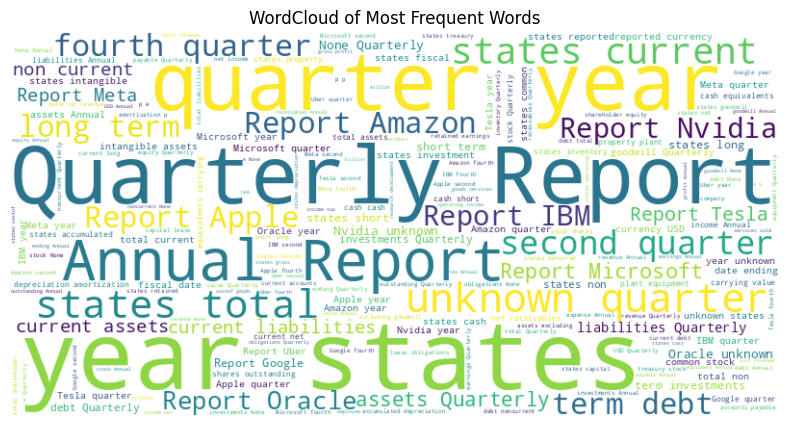

In [ ]:

import pandas as pd

# Path to your folder containing text files
data_folder = 'data/'

# Initialize an empty list to store the data
data = []
type_mapping = {
    "balance_sheet": "Balance Sheet",
    "income_statement": "Income Statement",
    "news": "News",
    "Wikipedia": "Wikipedia"
}

# Loop through all files in the folder
for filename in os.listdir(data_folder):
    if filename.endswith(".txt"):  # Check if the file is a text file
        file_path = os.path.join(data_folder, filename)
        with open(file_path, 'r', encoding='utf-8') as file:
            content = file.read()  # Read the file content
            parts = filename.split('_', 1)
            company = parts[0]
            file_type = parts[1].replace('.txt', '')  # Remove the file extension
            file_type_full = type_mapping.get(file_type, "Unknown")
            # Append the filename (without extension) and content to the list
            data.append({
                "Title": filename,
                "Company": company,
                "Type": file_type_full,
                "Content": content
            })

# Create a DataFrame from the list
df = pd.DataFrame(data)

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS as stopwords  # Stopwords list
print(stopwords)
# Step 2: Function to remove stopwords
def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word.lower() not in stopwords]
    return ' '.join(filtered_words)

# Apply the function to the 'Content' column
df['Content_cleaned'] = df['Content'].apply(remove_stopwords)
df.to_csv('df_cleaned.csv', index=False)

# Step 3: Combine all cleaned content into a single string

from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Step 4: Generate and plot the WordCloud
all_text = ' '.join(df['Content_cleaned'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud of Most Frequent Words')
plt.show()

In [ ]:
df.to_csv('df_cleaned.csv', index=False)

In [ ]:
df2 = pd.read_csv('df_cleaned.csv')
print(df2)

                             Title    Company              Type  \
0                     IBM_news.txt        IBM              News   
1                   Apple_news.txt      Apple              News   
2               Microsoft_news.txt  Microsoft              News   
3                  Amazon_news.txt     Amazon              News   
4                   Tesla_news.txt      Tesla              News   
5                    Uber_news.txt       Uber              News   
6                    Meta_news.txt       Meta              News   
7                  Google_news.txt     Google              News   
8                  Nvidia_news.txt     Nvidia              News   
9                  Oracle_news.txt     Oracle              News   
10      Apple_income_statement.txt      Apple  Income Statement   
11  Microsoft_income_statement.txt  Microsoft  Income Statement   
12     Amazon_income_statement.txt     Amazon  Income Statement   
13      Tesla_income_statement.txt      Tesla  Income Statemen

In [ ]:
print(df)

                             Title    Company              Type  \
0                     IBM_news.txt        IBM              News   
1                   Apple_news.txt      Apple              News   
2               Microsoft_news.txt  Microsoft              News   
3                  Amazon_news.txt     Amazon              News   
4                   Tesla_news.txt      Tesla              News   
5                    Uber_news.txt       Uber              News   
6                    Meta_news.txt       Meta              News   
7                  Google_news.txt     Google              News   
8                  Nvidia_news.txt     Nvidia              News   
9                  Oracle_news.txt     Oracle              News   
10      Apple_income_statement.txt      Apple  Income Statement   
11  Microsoft_income_statement.txt  Microsoft  Income Statement   
12     Amazon_income_statement.txt     Amazon  Income Statement   
13      Tesla_income_statement.txt      Tesla  Income Statemen